Assignment Topic : Transfer Learning Model Development using Pre-trained CNN for Plant Disease Classification

Research Paper Title : Using transfer learning-based plant disease classification and detection for sustainable agriculture

Course Name : Deep Learning

Student Name : Samriddhi Das

PRN : 202301040276

Group Members :
1. Samriddhi Das
2. Swayam Pagare
3. Jayesh Jadhav
4. Manish Korde

Dataset: PlantVillage Dataset


* Contains approximately 50,000+ images
* Includes multiple crop species, such as:
* Tomato
* Potato
* Corn
* Apple 
* Grape
* Covers around 38 different plant disease classes


In [29]:
import kagglehub
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [30]:
path = kagglehub.dataset_download("emmarex/plantdisease")
print("Dataset path:", path)

print(os.listdir(path))

Dataset path: /kaggle/input/datasets/emmarex/plantdisease
['PlantVillage', 'plantvillage']


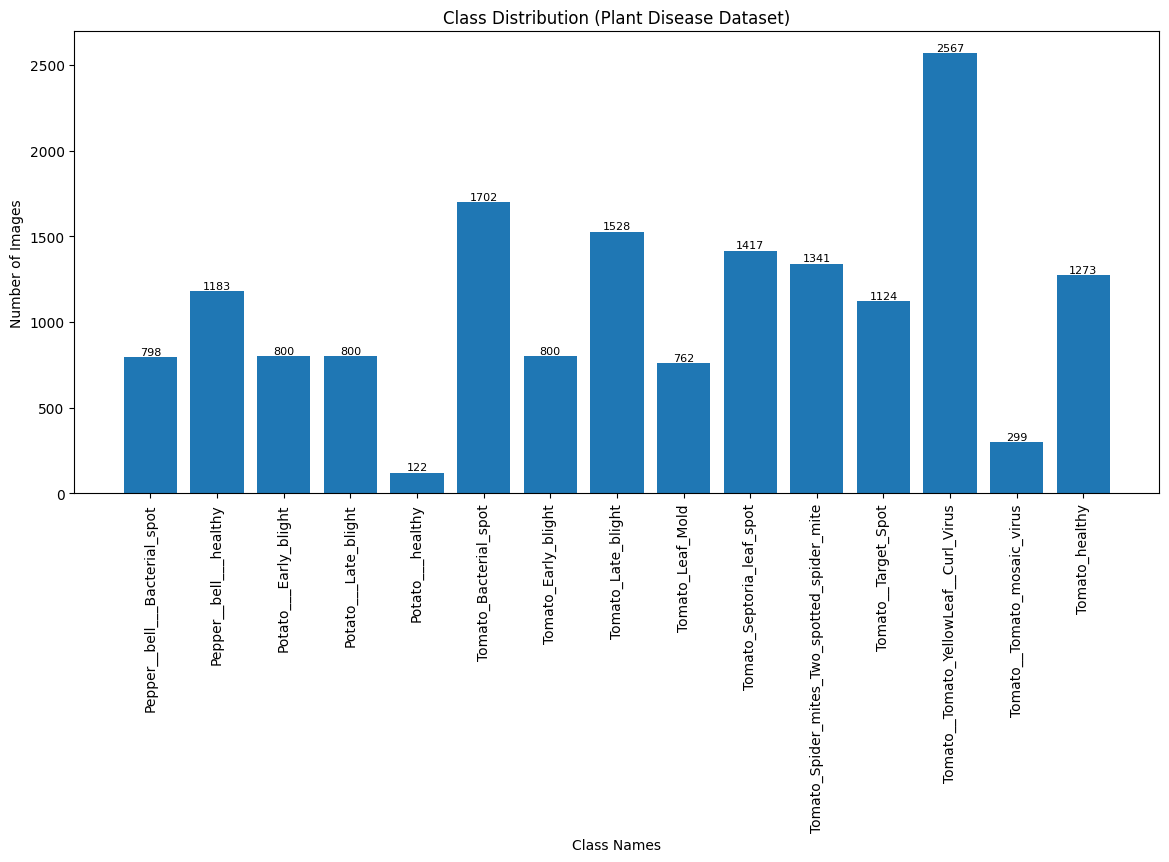

In [31]:
class_indices = train_data.class_indices
labels = dict((v, k) for k, v in class_indices.items())
class_counts = train_data.classes
unique, counts = np.unique(class_counts, return_counts=True)
class_names = [labels[i] for i in unique]

plt.figure(figsize=(14,6))
bars = plt.bar(class_names, counts)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=90)
plt.title("Class Distribution (Plant Disease Dataset)")
plt.xlabel("Class Names")
plt.ylabel("Number of Images")
plt.show()

In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

dataset_path = os.path.join(path, "PlantVillage")

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical',
    shuffle=False
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


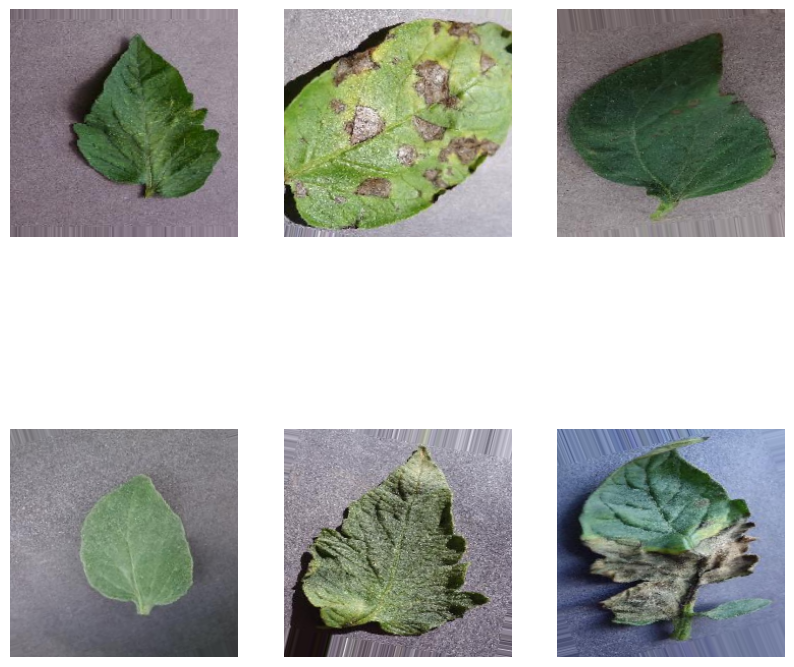

Classes: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [33]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

print("Classes:", train_data.class_indices)

TASK 2: MODEL IMPLEMENTATION

In [34]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [35]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 249s 466ms/step - accuracy: 0.6052 - loss: 1.2727 - val_accuracy: 0.8671 - val_loss: 0.4169
Epoch 2/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 227s 438ms/step - accuracy: 0.8382 - loss: 0.4965 - val_accuracy: 0.8705 - val_loss: 0.3757
Epoch 3/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 230s 444ms/step - accuracy: 0.8643 - loss: 0.4211 - val_accuracy: 0.8894 - val_loss: 0.3268
Epoch 4/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 233s 452ms/step - accuracy: 0.8647 - loss: 0.3987 - val_accuracy: 0.9061 - val_loss: 0.2821
Epoch 5/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 232s 448ms/step - accuracy: 0.8806 - loss: 0.3410 - val_accuracy: 0.9102 - val_loss: 0.2697
Epoch 6/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 229s 443ms/step - accuracy: 0.8832 - loss: 0.3364 - val_accuracy: 0.9083 - val_loss: 0.2741
Epoch 7/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 230s 446ms/step - accuracy: 0.8851 - loss: 0.3226 - val_accuracy: 0.9141 - val_loss: 0.2609
Epoch 8/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 231s 447ms/step - accuracy: 0.9024 - loss: 0

In [38]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

Epoch 1/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 260s 478ms/step - accuracy: 0.6769 - loss: 1.2591 - val_accuracy: 0.9017 - val_loss: 0.2992
Epoch 2/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 247s 477ms/step - accuracy: 0.8530 - loss: 0.4279 - val_accuracy: 0.8959 - val_loss: 0.3159
Epoch 3/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 238s 461ms/step - accuracy: 0.8753 - loss: 0.3699 - val_accuracy: 0.9071 - val_loss: 0.2815
Epoch 4/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 238s 461ms/step - accuracy: 0.8932 - loss: 0.3071 - val_accuracy: 0.9112 - val_loss: 0.2523
Epoch 5/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 243s 470ms/step - accuracy: 0.9020 - loss: 0.2882 - val_accuracy: 0.9178 - val_loss: 0.2297
Epoch 6/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 237s 458ms/step - accuracy: 0.9085 - loss: 0.2663 - val_accuracy: 0.9313 - val_loss: 0.1991
Epoch 7/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 235s 455ms/step - accuracy: 0.9191 - loss: 0.2449 - val_accuracy: 0.9284 - val_loss: 0.2084
Epoch 8/8
517/517 ━━━━━━━━━━━━━━━━━━━━ 236s 456ms/step - accuracy: 0.9205 - loss: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


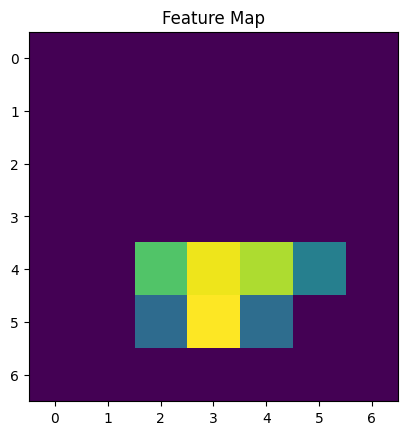

In [39]:
feature_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.output
)

sample = images[0:1]
feature_maps = feature_model.predict(sample)

plt.imshow(feature_maps[0,:,:,0], cmap='viridis')
plt.title("Feature Map")
plt.show()

TASK 3: EVALUATION

In [40]:
from sklearn.metrics import classification_report, confusion_matrix

pred = model.predict(val_data)
pred_classes = np.argmax(pred, axis=1)

true_classes = val_data.classes

print(classification_report(true_classes, pred_classes))

129/129 ━━━━━━━━━━━━━━━━━━━━ 55s 397ms/step
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       199
           1       0.97      0.98      0.98       295
           2       0.99      0.98      0.98       200
           3       0.96      0.96      0.96       200
           4       0.97      0.97      0.97        30
           5       0.95      0.96      0.96       425
           6       0.85      0.69      0.76       200
           7       0.94      0.89      0.91       381
           8       0.93      0.92      0.93       190
           9       0.88      0.94      0.91       354
          10       0.89      0.92      0.90       335
          11       0.84      0.84      0.84       280
          12       0.99      0.99      0.99       641
          13       0.97      0.96      0.97        74
          14       0.94      0.98      0.96       318

    accuracy                           0.93      4122
   macro avg       0.93      0.93   

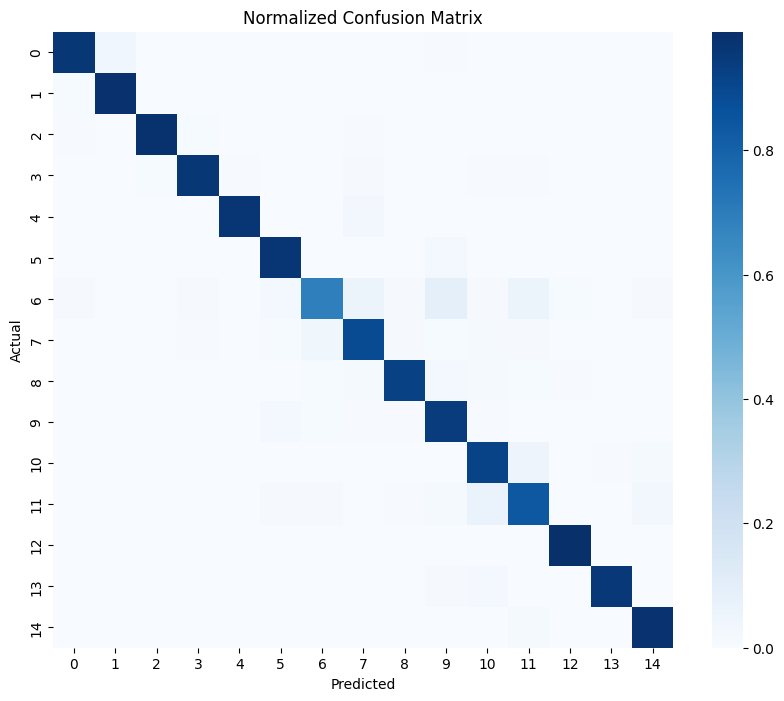

In [51]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

# Normalize
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

This graph shows how well the model classifies each class. The diagonal represents correct predictions, while other cells represent misclassifications

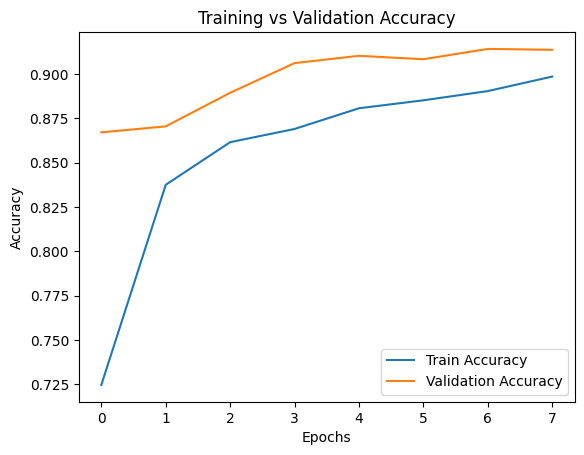

In [42]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

This graph shows how the model’s accuracy improves over epochs for both training and validation data

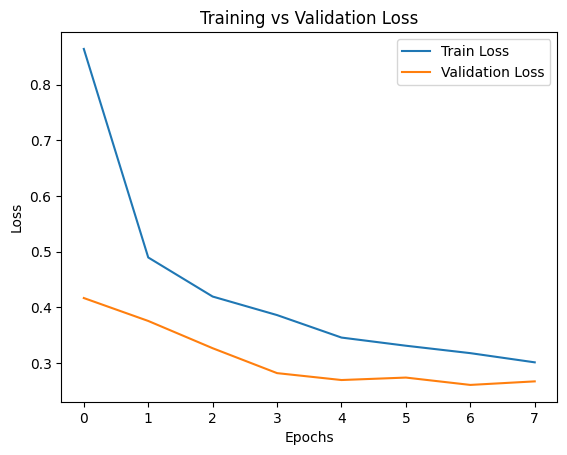

In [43]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

report = classification_report(true_classes, pred_classes, output_dict=True)

# Extract recall (per-class accuracy)
class_acc = {}
for class_id, metrics in report.items():
    if class_id.isdigit():
        class_acc[int(class_id)] = metrics['recall']

# Map class index → class name
labels = dict((v, k) for k, v in train_data.class_indices.items())

class_names = [labels[i] for i in class_acc.keys()]
values = list(class_acc.values())

plt.figure(figsize=(14,6))
bars = plt.bar(class_names, values)

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f"{yval:.2f}", ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=90)
plt.title("Per-Class Accuracy")
plt.xlabel("Class Names")
plt.ylabel("Accuracy")
plt.show()

This graph shows how the error decreases during training, indicating model learning

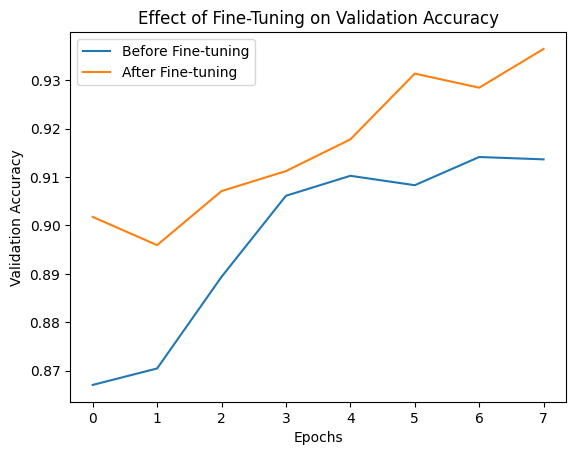

In [45]:

plt.figure()

plt.plot(history.history['val_accuracy'], label='Before Fine-tuning')
plt.plot(fine_history.history['val_accuracy'], label='After Fine-tuning')

plt.legend()
plt.title("Effect of Fine-Tuning on Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.show()

This graph compares model performance before and after fine-tuning, showing improvement due to transfer learning

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


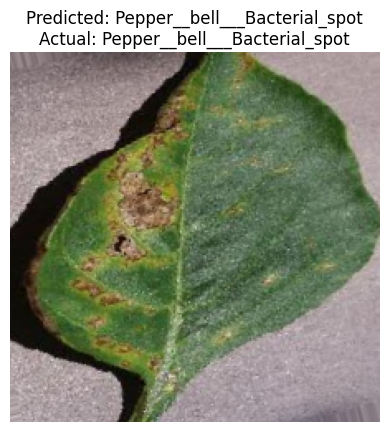

In [44]:

images, labels_batch = next(val_data)

preds = model.predict(images)

pred_class = np.argmax(preds[0])
true_class = np.argmax(labels_batch[0])

class_labels = list(train_data.class_indices.keys())

plt.imshow(images[0])
plt.title(f"Predicted: {class_labels[pred_class]}\nActual: {class_labels[true_class]}")
plt.axis('off')
plt.show()